In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

print("Tensorflow version:", tf.__version__)

Tensorflow version: 2.19.0


In [ ]:
vocab_size=10000
max_length=200
trunc_type='post'
padding_type='post'
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
X_train = pad_sequences(X_train, maxlen=max_length, padding=padding_type, truncating=trunc_type)
X_test = pad_sequences(X_test, maxlen=max_length, padding=padding_type, truncating=trunc_type)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (25000, 200)
Testing set shape: (25000, 200)


In [ ]:
embedding_dim = 32
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2,
                    callbacks=[Early_stopping])

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 261ms/step - accuracy: 0.5767 - loss: 0.6663 - val_accuracy: 0.6710 - val_loss: 0.6107
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 265ms/step - accuracy: 0.6360 - loss: 0.6388 - val_accuracy: 0.5994 - val_loss: 0.6716
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.5561 - loss: 0.6874 - val_accuracy: 0.5216 - val_loss: 0.6777


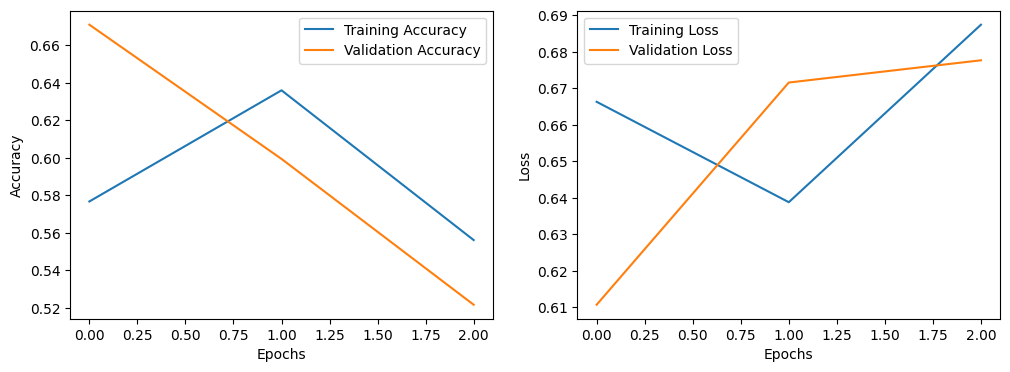

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.6600 - loss: 0.6176
Test accuracy: 0.6600000262260437


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

In [ ]:
from os import set_inheritable
word_index = imdb.get_word_index()
def encode_text(text):
    tokens = text.lower().split()
    tokens = [word_index.get(word, 0) for word in tokens]
    # Reshape the output to have a batch size of 1
    return pad_sequences([tokens], maxlen=max_length, padding=padding_type, truncating=trunc_type)[0].reshape(1, -1)
sample_reviews = ["This movie was fantastic! i really love it",
                  "i hated this movie . i was terrible "]
for review in sample_reviews:
    encoded_review = encode_text(review)
    prediction = model.predict(encoded_review)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment} (score: {prediction:.3f})")
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
Review: This movie was fantastic! i really love it
Sentiment: Negative (score: 0.383)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Review: i hated this movie . i was terrible 
Sentiment: Negative (score: 0.383)
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.6600 - loss: 0.6176
Test Loss: 0.6176053285598755
Test Accuracy: 0.6600000262260437


In [ ]:
Early_stopping=EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)
history=model.fit(X_train,y_train,
                  epochs=10,
                  batch_size=128,
                  validation_split=0.2,
                  callbacks=[Early_stopping])

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 261ms/step - accuracy: 0.7042 - loss: 0.5843 - val_accuracy: 0.7370 - val_loss: 0.5676
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 256ms/step - accuracy: 0.6366 - loss: 0.6193 - val_accuracy: 0.6140 - val_loss: 0.6304
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 268ms/step - accuracy: 0.5867 - loss: 0.6465 - val_accuracy: 0.4938 - val_loss: 0.6914
